This notebook shows how to setup a new project, train a keypoint-MoSeq model and visualize the resulting syllables.

**Total run time: ~90 min.**

# Colab setup

- Make a copy of this notebook if you plan to make changes and want them saved.
- Go to "Runtime">"change runtime type" and select "Python 3" and "GPU"

### Install keypoint MoSeq

A100　　1

In [3]:
from google.colab import drive

In [4]:
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!nvidia-smi

Wed Oct  7 06:22:41 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX PRO 6000 Blac...    Off |   00000000:05:00.0 Off |                    0 |
| N/A   25C    P0             46W /  600W |       0MiB /  97887MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [1]:
!pip install -U keypoint-moseq

In [6]:
import os

import numpy as np

import keypoint_moseq as kpms

from google.colab import drive, output

XlaRuntimeError: UNIMPLEMENTED: /usr/local/lib/python3.11/dist-packages/nvidia/cuda_nvcc/bin/ptxas ptxas too old. Falling back to the driver to compile.

In [10]:
!python --version

Python 3.11.13


In [12]:
!ptxas --version

ptxas: NVIDIA (R) Ptx optimizing assembler
Copyright (c) 2005-2024 NVIDIA Corporation
Built on Thu_Jun__6_02:14:54_PDT_2024
Cuda compilation tools, release 12.5, V12.5.82
Build cuda_12.5.r12.5/compiler.34385749_0


In [11]:
!pip show jax jaxlib | grep -E "Name|Version"

Name: jax
Version: 0.5.2
Name: jaxlib
Version: 0.5.1


In [13]:
!pip show nvidia-cuda-nvcc-cu12 | grep Version

Version: 12.5.82


In [1]:
!pip install -U nvidia-cuda-nvcc-cu12

1衣奈

In [2]:
!pip install -U keypoint-moseq

import os
import numpy as np
import keypoint_moseq as kpms

from google.colab import drive, output

drive.mount("/content/drive")
output.enable_custom_widget_manager()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Option 1: Use our example dataset

In [ ]:
import gdown

url = "https://drive.google.com/uc?id=1JGyS9MbdS3MtrlYnh4xdEQwe2bYoCuSZ"
output = "dlc_example_project.zip"
gdown.download(url, output, quiet=False)
! unzip dlc_example_project.zip

data_dir = "dlc_example_project"

Downloading...
From (original): https://drive.google.com/uc?id=1JGyS9MbdS3MtrlYnh4xdEQwe2bYoCuSZ
From (redirected): https://drive.google.com/uc?id=1JGyS9MbdS3MtrlYnh4xdEQwe2bYoCuSZ&confirm=t&uuid=759eeecd-d552-41a0-878e-f38cd624aa55
To: /content/dlc_example_project.zip
100%|██████████| 302M/302M [00:04<00:00, 62.0MB/s]


Archive:  dlc_example_project.zip
   creating: dlc_example_project/
  inflating: dlc_example_project/config.yaml  
   creating: dlc_example_project/videos/
  inflating: dlc_example_project/videos/21_12_10_def6a_3.top.ir.mp4  
  inflating: dlc_example_project/videos/22_04_26_cage4_1_1.top.ir.mp4  
  inflating: dlc_example_project/videos/21_12_10_def6b_3.top.irDLC_resnet50_moseq_exampleAug21shuffle1_500000.h5  
  inflating: dlc_example_project/videos/21_12_2_def6a_1.top.irDLC_resnet50_moseq_exampleAug21shuffle1_500000.h5  
  inflating: dlc_example_project/videos/21_12_10_def6a_1_1.top.ir.mp4  
  inflating: dlc_example_project/videos/21_12_10_def6a_3.top.irDLC_resnet50_moseq_exampleAug21shuffle1_500000.h5  
  inflating: dlc_example_project/videos/22_27_04_cage4_mouse2_0.top.ir.mp4  
  inflating: dlc_example_project/videos/22_04_26_cage4_0_2.top.irDLC_resnet50_moseq_exampleAug21shuffle1_500000.h5  
  inflating: dlc_example_project/videos/22_04_26_cage4_0.top.ir.mp4  
  inflating: dlc_examp

### Option 2: Use your own data
Upload your data to google drive and then change the following path as needed

2衣奈

In [3]:
data_dir = "/content/drive/MyDrive/ena_deta"

project_dir = "/content/ena_project/"
config = lambda: kpms.load_config(project_dir)

# Project setup
Create a new project directory with a keypoint-MoSeq `config.yml` file.

In [ ]:
import keypoint_moseq as kpms
import numpy as np

project_dir = "/content/demo_project/"
config = lambda: kpms.load_config(project_dir)

KeyboardInterrupt: 

In [ ]:
import keypoint_moseq as kpms
import numpy as np

project_dir = "/content/ena_project/"
config = lambda: kpms.load_config(project_dir)

In [ ]:
kpms.update_config(
    project_dir,

    bodyparts=[
        "tailbase",
        "body3",
        "body2",
        "body1",
        "head",
        "nose",
        "rightear",
        "leftear",
    ],

    use_bodyparts=[
        "tailbase",
        "body3",
        "body2",
        "body1",
        "head",
        "nose",
        "rightear",
        "leftear",
    ],

    anterior_bodyparts=["nose"],
    posterior_bodyparts=["tailbase"],

    skeleton=[
        ["tailbase", "body3"],
        ["body3", "body2"],
        ["body2", "body1"],
        ["body1", "head"],
        ["head", "nose"],
        ["head", "rightear"],
        ["head", "leftear"],
    ],

    fps=30,
)

In [ ]:
print("bodyparts:", config()["bodyparts"])
print("use_bodyparts:", config()["use_bodyparts"])
print("anterior:", config()["anterior_bodyparts"])
print("posterior:", config()["posterior_bodyparts"])
print("skeleton:", config()["skeleton"])
print("fps:", config()["fps"])

bodyparts: ['tailbase', 'body3', 'body2', 'body1', 'head', 'nose', 'rightear', 'leftear']
use_bodyparts: ['tailbase', 'body3', 'body2', 'body1', 'head', 'nose', 'rightear', 'leftear']
anterior: ['nose']
posterior: ['tailbase']
skeleton: [['tailbase', 'body3'], ['body3', 'body2'], ['body2', 'body1'], ['body1', 'head'], ['head', 'nose'], ['head', 'rightear'], ['head', 'leftear']]
fps: 30


In [ ]:
kpms.update_config(
    project_dir,
    outlier_scale_factor=6.0
)

coordinates, confidences = kpms.outlier_removal(
    coordinates,
    confidences,
    project_dir,
    overwrite=False,
    **config()
)

### Option 1: Setup from DeepLabCut

In [ ]:
dlc_config = os.path.join(data_dir, "config.yaml")
kpms.setup_project(project_dir, deeplabcut_config=dlc_config)

In [10]:
!which ptxas && ptxas --version

/usr/local/cuda/bin/ptxas
ptxas: NVIDIA (R) Ptx optimizing assembler
Copyright (c) 2005-2024 NVIDIA Corporation
Built on Thu_Jun__6_02:14:54_PDT_2024
Cuda compilation tools, release 12.5, V12.5.82
Build cuda_12.5.r12.5/compiler.34385749_0


In [12]:
!find /usr/local/lib/python3.11/dist-packages/nvidia -name ptxas 2>/dev/null

/usr/local/lib/python3.11/dist-packages/nvidia/cuda_nvcc/bin/ptxas


In [14]:
!/usr/local/lib/python3.11/dist-packages/nvidia/cuda_nvcc/bin/ptxas --version

ptxas: NVIDIA (R) Ptx optimizing assembler
Copyright (c) 2005-2024 NVIDIA Corporation
Built on Thu_Jun__6_02:14:54_PDT_2024
Cuda compilation tools, release 12.5, V12.5.82
Build cuda_12.5.r12.5/compiler.34385749_0


In [15]:
!pip show jax jaxlib

Name: jax
Version: 0.5.2
Summary: Differentiate, compile, and transform Numpy code.
Home-page: https://github.com/jax-ml/jax
Author: JAX team
Author-email: jax-dev@google.com
License: Apache-2.0
Location: /usr/local/lib/python3.11/dist-packages
Requires: jaxlib, ml_dtypes, numpy, opt_einsum, scipy
Required-by: chex, dopamine_rl, dynamax, flax, keypoint-moseq, optax, orbax-checkpoint
---
Name: jaxlib
Version: 0.5.1
Summary: XLA library for JAX
Home-page: https://github.com/jax-ml/jax
Author: JAX team
Author-email: jax-dev@google.com
License: Apache-2.0
Location: /usr/local/lib/python3.11/dist-packages
Requires: ml-dtypes, numpy, scipy
Required-by: chex, dopamine_rl, dynamax, jax, keypoint-moseq, optax


In [16]:
!pip list | grep -E "jax|cuda"

cuda-python                           12.6.2.post1
cupy-cuda12x                          13.3.0
dask-cuda                             25.2.0
jax                                   0.5.2
jax-cuda12-pjrt                       0.5.1
jax-cuda12-plugin                     0.5.1
jax-moseq                             0.3.5
jaxlib                                0.5.1
jaxtyping                             0.3.11
numba-cuda                            0.2.0
nvidia-cuda-cupti-cu12                12.5.82
nvidia-cuda-nvcc-cu12                 12.5.82
nvidia-cuda-nvrtc-cu12                12.5.82
nvidia-cuda-runtime-cu12              12.5.82


3衣奈

In [4]:
kpms.setup_project(project_dir)

In [10]:
!unzip -q /content/drive/MyDrive/ena_deta-20261003T065829Z-1-001.zip -d /content/drive/MyDrive/

4衣奈

In [5]:
keypoint_data_path = data_dir

coordinates, confidences, bodyparts = kpms.load_keypoints(
    keypoint_data_path,
    "deeplabcut"
)

print(bodyparts)

Loading keypoints: 100%|████████████████| 18/18 [00:18<00:00,  1.03s/it]

['tailbase', 'body3', 'body2', 'body1', 'head', 'nose', 'rightear', 'leftear']


In [ ]:
video_dir="/content/drive/MyDrive/ena_deta",

In [ ]:
keypoint_data_path = "/content/drive/MyDrive/ena_deta"

coordinates, confidences, bodyparts = kpms.load_keypoints(
    keypoint_data_path,
    "deeplabcut"
)

print(bodyparts)

Loading keypoints: 100%|████████████████| 18/18 [00:21<00:00,  1.19s/it]

['tailbase', 'body3', 'body2', 'body1', 'head', 'nose', 'rightear', 'leftear']


### Option 2: Setup from SLEAP

In [ ]:
import os
import glob
import h5py

files = glob.glob("/content/drive/MyDrive/ena_deta/*.h5")

print("H5ファイル数:", len(files))

for file in files:
    try:
        with h5py.File(file, "r") as f:
            pass
        print("正常 :", os.path.basename(file),
              round(os.path.getsize(file)/1024/1024, 2), "MB")
    except Exception as e:
        print("破損 :", os.path.basename(file),
              round(os.path.getsize(file)/1024/1024, 2), "MB")
        print("       ", e)

H5ファイル数: 18
正常 : TM_20231021.h5 9.74 MB
正常 : TM_20231022.h5 9.74 MB
正常 : TM_20231110.h5 9.74 MB
正常 : TM_20231111.h5 9.74 MB
正常 : TM_20240110.h5 9.82 MB
正常 : TM_20240111.h5 9.74 MB
正常 : TM_20240509.h5 9.82 MB
正常 : TM_20240510.h5 9.82 MB
正常 : TM_20240627.h5 9.74 MB
正常 : WM_20231021.h5 9.74 MB
正常 : WM_20231022.h5 9.68 MB
正常 : WM_20231110.h5 9.74 MB
正常 : WM_20231111.h5 9.74 MB
正常 : WM_20240110.h5 9.82 MB
正常 : WM_20240111.h5 9.82 MB
正常 : WM_20240509.h5 9.86 MB
正常 : WM_20240510.h5 9.82 MB
正常 : WM_20240627.h5 9.78 MB


In [ ]:
# choose a .h5 file for one of your recordings
# sleap_file = os.path.join(data_dir, 'SLEAP_FILE_NAME')
# kpms.setup_project(project_dir, sleap_file=sleap_file)

### Options 3: Manual setup

In [ ]:
# bodyparts=[
#     'tail', 'spine4', 'spine3', 'spine2', 'spine1',
#     'head', 'nose', 'right ear', 'left ear']

# skeleton=[
#     ['tail', 'spine4'],
#     ['spine4', 'spine3'],
#     ['spine3', 'spine2'],
#     ['spine2', 'spine1'],
#     ['spine1', 'head'],
#     ['nose', 'head'],
#     ['left ear', 'head'],
#     ['right ear', 'head']]

# video_dir = os.path.join(data_dir, 'videos')

# kpms.setup_project(
#     project_dir,
#     video_dir=video_dir,
#     bodyparts=bodyparts,
#     skeleton=skeleton)

## Edit the config file

The config can be edited in a text editor or using the function `kpms.update_config`, as shown below. In general, the following parameters should be specified for each project:

- `bodyparts` (name of each keypoint; automatically imported from SLEAP/DeepLabCut)
- `use_bodyparts` (subset of bodyparts to use for modeling, set to all bodyparts by default; for mice we recommend excluding the tail)
- `anterior_bodyparts` and `posterior_bodyparts` (used for rotational alignment)
- `video_dir` (directory with videos of each experiment)
- `fps` (frames per second of the input videos)

Edit the config as follows for the [example DeepLabCut dataset](https://drive.google.com/drive/folders/1UNHQ_XCQEKLPPSjGspRopWBj6-YNDV6G?usp=share_link):

In [ ]:
kpms.update_config(
    project_dir,
    video_dir=os.path.join(data_dir, "videos"),
    anterior_bodyparts=["nose"],
    posterior_bodyparts=["spine4"],
    use_bodyparts=["spine4", "spine3", "spine2", "spine1", "head", "nose", "right ear", "left ear"],
    fps=30,
)

## Load data

The code below shows how to load keypoint detections from DeepLabCut. To load other formats, replace `'deeplabcut'` in the example with one of `'sleap', 'anipose', 'sleap-anipose', 'nwb'`. For other formats, see the [FAQ](https://keypoint-moseq.readthedocs.io/en/latest/FAQs.html#loading-keypoint-tracking-data).

In [ ]:
# load data (e.g. from DeepLabCut)
keypoint_data_path = os.path.join(
    data_dir, "videos"
)  # can be a file, a directory, or a list of files
coordinates, confidences, bodyparts = kpms.load_keypoints(keypoint_data_path, "deeplabcut")

# format data for modeling
data, metadata = kpms.format_data(coordinates, confidences, **config())

Loading keypoints: 100%|████████████████| 10/10 [00:00<00:00, 17.69it/s]


In [ ]:
data, metadata = kpms.format_data(
    coordinates,
    confidences,
    **config()
)

In [ ]:
keypoint_data_path = "/content/drive/MyDrive/ena_deta"

coordinates, confidences, bodyparts = kpms.load_keypoints(
    keypoint_data_path,
    "deeplabcut"
)

print("DLCのbodyparts:")
print(bodyparts)

print("\nconfigのbodyparts:")
print(config()["bodyparts"])

print("\nuse_bodyparts:")
print(config()["use_bodyparts"])

Loading keypoints: 100%|████████████████| 18/18 [00:01<00:00, 14.88it/s]


DLCのbodyparts:
['tailbase', 'body3', 'body2', 'body1', 'head', 'nose', 'rightear', 'leftear']

configのbodyparts:
['tail', 'spine4', 'spine3', 'spine2', 'spine1', 'head', 'nose', 'right ear', 'left ear']

use_bodyparts:
['spine4', 'spine3', 'spine2', 'spine1', 'head', 'nose', 'right ear', 'left ear']


In [ ]:
kpms.update_config(
    project_dir,
    video_dir="/content/drive/MyDrive/ena_deta",
    anterior_bodyparts=["nose"],
    posterior_bodyparts=["tailbase"],
    use_bodyparts=[
        "tailbase",
        "body3",
        "body2",
        "body1",
        "head",
        "nose",
        "rightear",
        "leftear"
    ],
    fps=30,
)

5衣奈

In [6]:
kpms.update_config(
    project_dir,

    bodyparts=[
        "tailbase",
        "body3",
        "body2",
        "body1",
        "head",
        "nose",
        "rightear",
        "leftear",
    ],

    use_bodyparts=[
        "tailbase",
        "body3",
        "body2",
        "body1",
        "head",
        "nose",
        "rightear",
        "leftear",
    ],

    anterior_bodyparts=["nose"],
    posterior_bodyparts=["tailbase"],

    skeleton=[
        ["tailbase", "body3"],
        ["body3", "body2"],
        ["body2", "body1"],
        ["body1", "head"],
        ["head", "nose"],
        ["head", "rightear"],
        ["head", "leftear"],
    ],

    fps=30,
)

6衣奈

In [7]:
print("bodyparts:", config()["bodyparts"])
print("use_bodyparts:", config()["use_bodyparts"])
print("anterior:", config()["anterior_bodyparts"])
print("posterior:", config()["posterior_bodyparts"])
print("skeleton:", config()["skeleton"])
print("fps:", config()["fps"])

bodyparts: ['tailbase', 'body3', 'body2', 'body1', 'head', 'nose', 'rightear', 'leftear']
use_bodyparts: ['tailbase', 'body3', 'body2', 'body1', 'head', 'nose', 'rightear', 'leftear']
anterior: ['nose']
posterior: ['tailbase']
skeleton: [['tailbase', 'body3'], ['body3', 'body2'], ['body2', 'body1'], ['body1', 'head'], ['head', 'nose'], ['head', 'rightear'], ['head', 'leftear']]
fps: 30


In [ ]:
keypoint_data_path = "/content/drive/MyDrive/ena_deta"

coordinates, confidences, bodyparts = kpms.load_keypoints(
    keypoint_data_path, "deeplabcut"
)

data, metadata = kpms.format_data(
    coordinates, confidences, **config()
)

Loading keypoints: 100%|████████████████| 18/18 [00:01<00:00, 16.28it/s]


ACTION REQUIRED: `skeleton` contains tail which is not one of the
  options in `bodyparts`.

ACTION REQUIRED: `skeleton` contains spine4 which is not one of the
  options in `bodyparts`.

ACTION REQUIRED: `skeleton` contains spine4 which is not one of the
  options in `bodyparts`.

ACTION REQUIRED: `skeleton` contains spine3 which is not one of the
  options in `bodyparts`.

ACTION REQUIRED: `skeleton` contains spine3 which is not one of the
  options in `bodyparts`.

ACTION REQUIRED: `skeleton` contains spine2 which is not one of the
  options in `bodyparts`.

ACTION REQUIRED: `skeleton` contains spine2 which is not one of the
  options in `bodyparts`.

ACTION REQUIRED: `skeleton` contains spine1 which is not one of the
  options in `bodyparts`.

ACTION REQUIRED: `skeleton` contains spine1 which is not one of the
  options in `bodyparts`.

ACTION REQUIRED: `skeleton` contains left ear which is not one of the
  options in `bodyparts`.

ACTION REQUIRED: `skeleton` contains right ear whi

## Remove outlier keypoints
Removing large outliers can improve the robustness of model fitting. The following cell classifies keypoints as outliers based on their distance to the animal's medoid. The outlier keypoints are then interpolated and their confidences are set to 0.
- Use `outlier_scale_factor` to set the upper distance threshold (higher values -> higher threshold, fewer points removed)
- Plots showing distance to medoid before and after outlier interpolation are saved to `{project_dir}/QA/plots/`
- Plotting can take a few minutes, so by default plots will not be regenerated when re-running this cell. To experiment with the effects of setting different values for outlier_scale_factor, set `overwrite=True` in outlier_removal.

7衣奈

In [8]:
kpms.update_config(project_dir, outlier_scale_factor=6.0)

coordinates, confidences = kpms.outlier_removal(
    coordinates,
    confidences,
    project_dir,
    overwrite=False,
    **config()
)

## Format data for modeling

8衣奈

In [9]:
data, metadata = kpms.format_data(coordinates, confidences, **config())

## Calibration

The purpose of calibration is to learn the relationship between keypoint errors and confidence scores. The results are stored using the `slope` and `intercept` parameters in the config.

- Run the cell below. A widget should appear with a video frame and the name of a bodypart. A yellow marker denotes the detected location of the bodypart.
    
- Annotate each frame with the correct location of the labeled bodypart
    - Click on the image at the correct location - an "X" should appear.
    - Use the prev/next buttons to annotate additional frames.
    - Click and drag the bottom-right shaded corner of the widget to adjust image size.
    - Use the toolbar to the left of the figure to pan and zoom.

- We suggest annotating at least 50 frames.

- Annotations will be automatically saved once you've completed at least 20 annotations.
Each new annotation after that will trigger an auto-save of all your work.
The message at the top of the widget will indicate when your annotations are being saved.

In [ ]:
kpms.update_config(
    project_dir,
    video_dir="/content/drive/MyDrive/ena_deta"
)

In [ ]:
import os

base = "/content/drive/MyDrive"

for name in os.listdir(base):
    if "ena" in name.lower():
        full_path = os.path.join(base, name)
        print("フォルダ名:", repr(name))
        print("正確なパス:", repr(full_path))
        print("存在:", os.path.isdir(full_path))

フォルダ名: 'ena_deta'
正確なパス: '/content/drive/MyDrive/ena_deta'
存在: True


9衣奈

Loading sample frames: 100%|██████████| 100/100 [00:36<00:00,  2.72it/s]


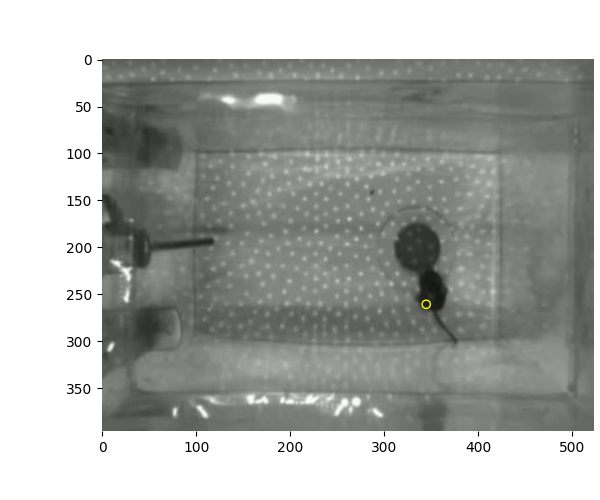

In [14]:
%matplotlib widget
kpms.noise_calibration(project_dir, coordinates, confidences, **config())

In [11]:
kpms.update_config(
    project_dir,
    video_dir="/content/drive/MyDrive/ena_deta"
)

In [12]:
from google.colab import output

In [13]:
output.enable_custom_widget_manager()

## Fit PCA

Run the cell below to fit a PCA model to aligned and centered keypoint coordinates.

- The model is saved to ``{project_dir}/pca.p`` and can be reloaded using ``kpms.load_pca``.
- Two plots are generated: a cumulative [scree plot](https://en.wikipedia.org/wiki/Scree_plot) and a depiction of each PC, where translucent nodes/edges represent the mean pose and opaque nodes/edges represent a perturbation in the direction of the PC.
- After fitting, edit `latent_dimension` in the config. This determines the dimension of the pose trajectory used to fit keypoint-MoSeq. A good heuristic is the number of dimensions needed to explain 90% of variance, or 10 dimensions - whichever is lower.  

10衣奈

>=90.0% of variance exlained by 4 components.


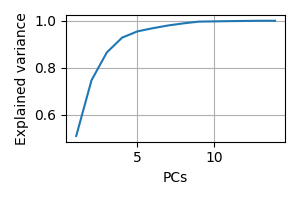

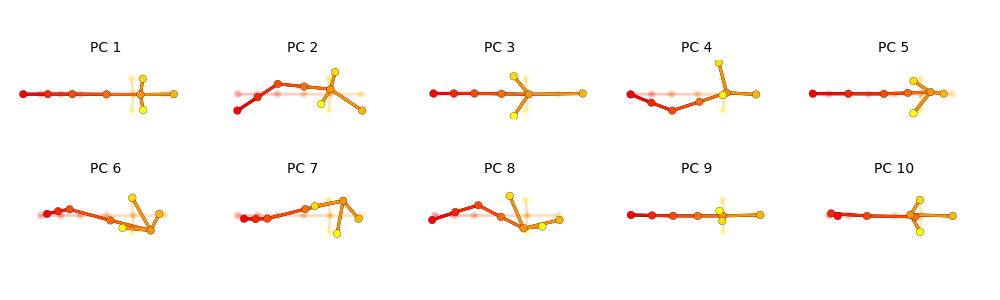

In [15]:
pca = kpms.fit_pca(**data, **config())
kpms.save_pca(pca, project_dir)

kpms.print_dims_to_explain_variance(pca, 0.9)
kpms.plot_scree(pca, project_dir=project_dir)
kpms.plot_pcs(pca, project_dir=project_dir, **config())

# use the following to load an already fit model
# pca = kpms.load_pca(project_dir)

11衣奈

In [16]:
kpms.update_config(project_dir, latent_dim=4)

# Model fitting

Fitting a keypoint-MoSeq model involves:
1. **Estimating hyperparameters:** Set model hyperparameters that can be automatically estimated from the input data.
2. **Initialization:** Auto-regressive (AR) parameters and syllable sequences are randomly initialized using pose trajectories from PCA.
3. **Fitting an AR-HMM:** The AR parameters, transition probabilities and syllable sequences are iteratively updated through Gibbs sampling.
4. **Fitting the full model:** All parameters, including both the AR-HMM as well as centroid, heading, noise-estimates and continuous latent states (i.e. pose trajectories) are iteratively updated through Gibbs sampling. This step is especially useful for noisy data.
5. **Extracting model results:** The learned states of the model are parsed and saved to disk for vizualization and downstream analysis.
6. **[Optional] Applying the trained model:** The learned model parameters can be used to infer a syllable sequences for additional data.

## Setting kappa

Most users will need to adjust the **kappa** hyperparameter to achieve the desired distribution of syllable durations. For this tutorial we chose kappa values that yielded a median syllable duration of 400ms (12 frames). Most users will need to tune kappa to their particular dataset. Higher values of kappa lead to longer syllables. **You will need to pick two kappas: one for AR-HMM fitting and one for the full model.**
- We recommend iteratively updating kappa and refitting the model until the target syllable time-scale is attained.  
- Model fitting can be stopped at any time by interrupting the kernel, and then restarted with a new kappa value.
- The full model will generally require a lower value of kappa to yield the same target syllable durations.
- To adjust the value of kappa in the model, use `kpms.update_hypparams` as shown below. Note that this command only changes kappa in the model dictionary, not the kappa value in the config file. The value in the config is only used during model initialization.

## Estimating Hyperparameters

We provide heuristics for adjusting a subset of model hyperparameters:

- **sigmasq_loc:** The expected distance that the centroid will move each frame. If this is set too high, the centroid trajectory will be overly noisy. If it's set too low, the centroid may deviate from the animal's true location during fast locomotion. `estimate_sigmasq_loc` estimates this hyperparameter based on the empirical frame-to-frame movement of the filtered centroid trajectory.

12衣奈

In [17]:
kpms.update_config(
    project_dir,
    sigmasq_loc=kpms.estimate_sigmasq_loc(data["Y"], data["mask"], filter_size=config()["fps"])
)

## Initialization

13衣奈

In [18]:
model = kpms.init_model(
    data,
    pca=pca,
    **config(),
    location_aware=True
)
model = kpms.update_hypparams(
    model,
    kappa=3e4
)

## Fitting an AR-HMM

In addition to fitting an AR-HMM, the function below:
- generates a name for the model and a corresponding directory in `project_dir`
- saves a checkpoint every 25 iterations from which fitting can be restarted
- plots the progress of fitting every 25 iterations, including
    - the distributions of syllable frequencies and durations for the most recent iteration
    - the change in median syllable duration across fitting iterations
    - a sample of the syllable sequence across iterations in a random window

14衣奈

Outputs will be saved to /content/ena_project/2026_10_08-09_11_10


 49%|█████████████████▏                 | 25/51 [01:10<01:06,  2.57s/it]

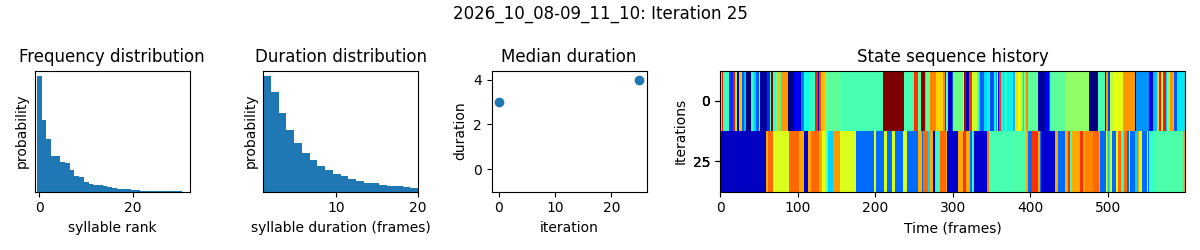

 98%|██████████████████████████████████▎| 50/51 [02:14<00:02,  2.58s/it]

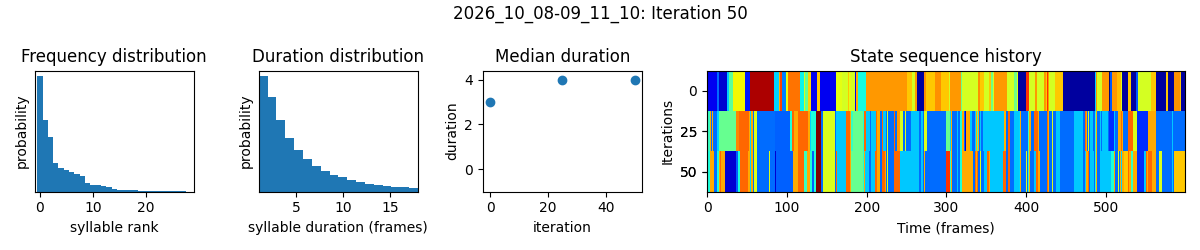

100%|███████████████████████████████████| 51/51 [02:17<00:00,  2.70s/it]


In [19]:
num_ar_iters = 50

model, model_name = kpms.fit_model(
    model, data, metadata, project_dir, ar_only=True, num_iters=num_ar_iters,
)

## Fitting the full model

The following code fits a full keypoint-MoSeq model using the results of AR-HMM fitting for initialization. If using your own data, you may need to try a few values of kappa at this step.

15衣奈

Outputs will be saved to /content/ena_project/2026_10_08-09_11_10


  5%|█▋                                | 25/501 [03:24<59:12,  7.46s/it]

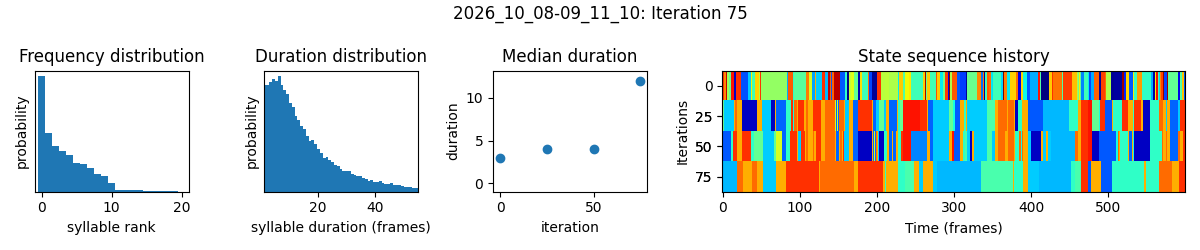

 10%|███▍                              | 50/501 [06:30<55:58,  7.45s/it]

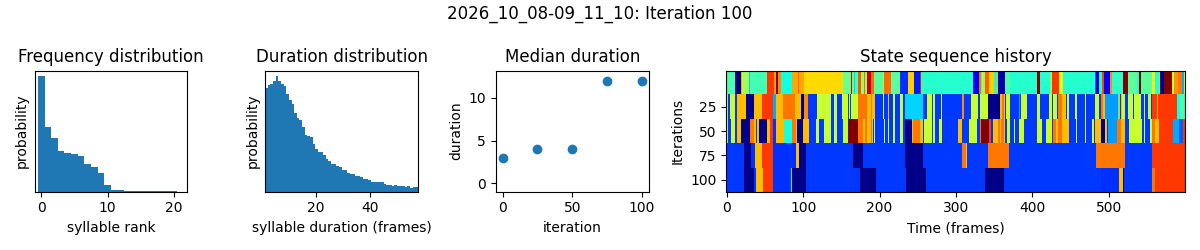

 15%|█████                             | 75/501 [09:36<52:46,  7.43s/it]

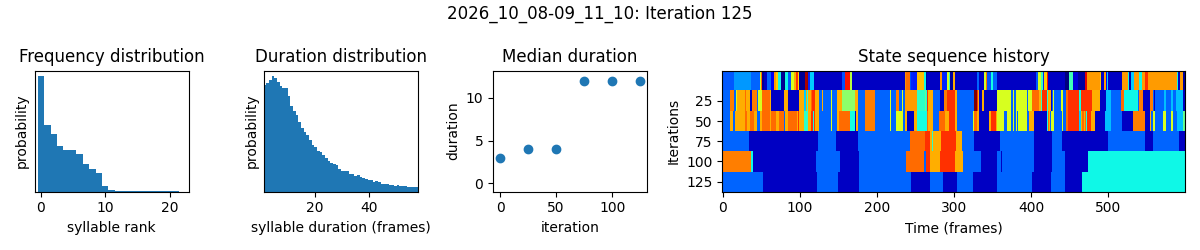

 20%|██████▌                          | 100/501 [12:43<49:44,  7.44s/it]

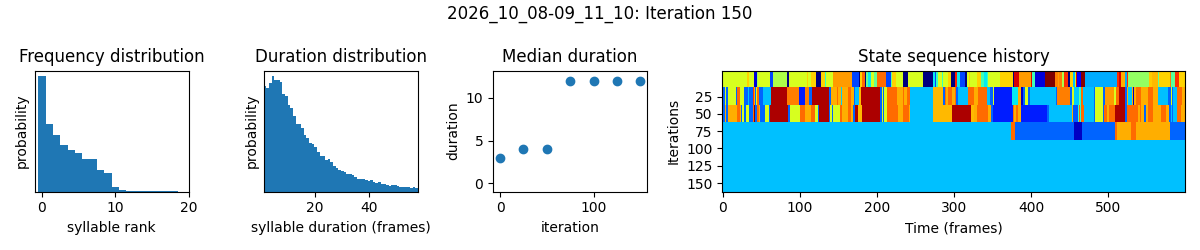

 25%|████████▏                        | 125/501 [15:49<46:42,  7.45s/it]

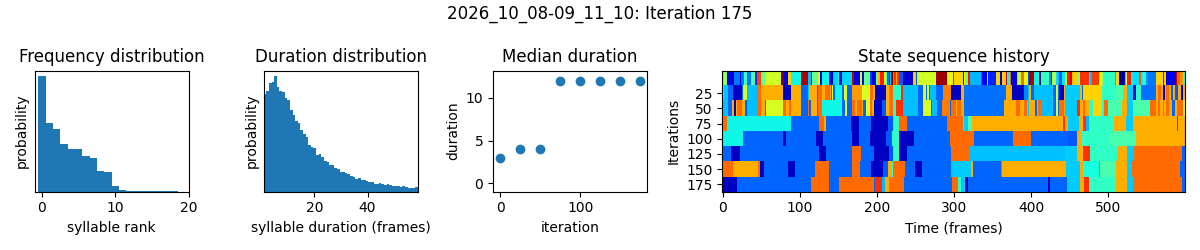

 30%|█████████▉                       | 150/501 [18:56<43:36,  7.45s/it]

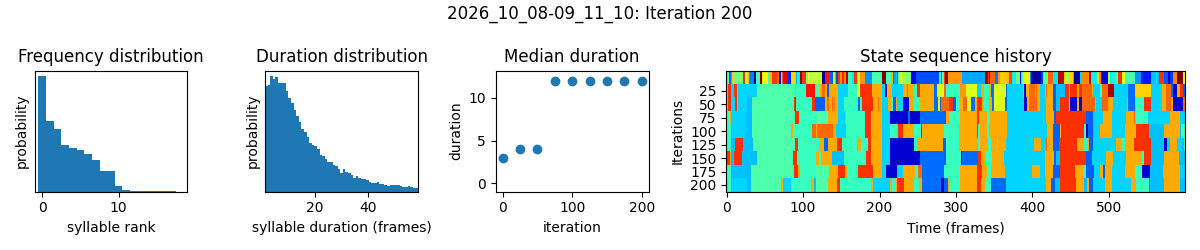

 35%|███████████▌                     | 175/501 [22:02<40:27,  7.44s/it]

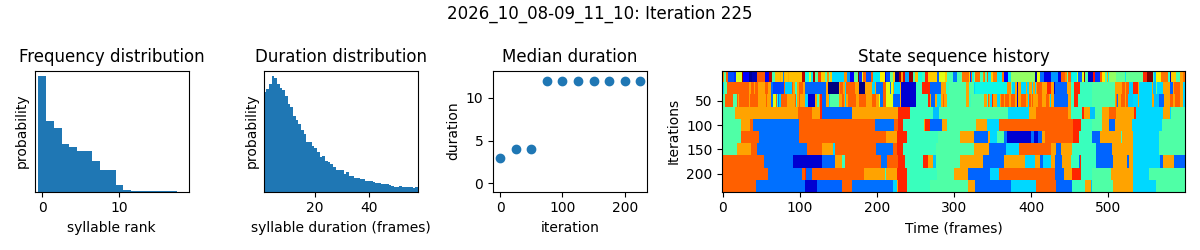

 40%|█████████████▏                   | 200/501 [25:09<37:22,  7.45s/it]

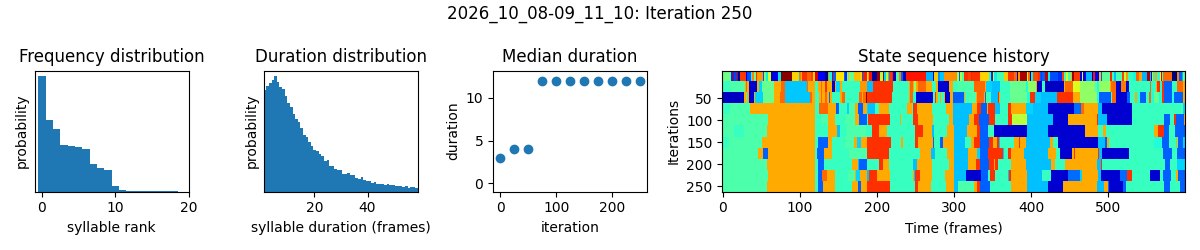

 45%|██████████████▊                  | 225/501 [28:15<34:17,  7.46s/it]

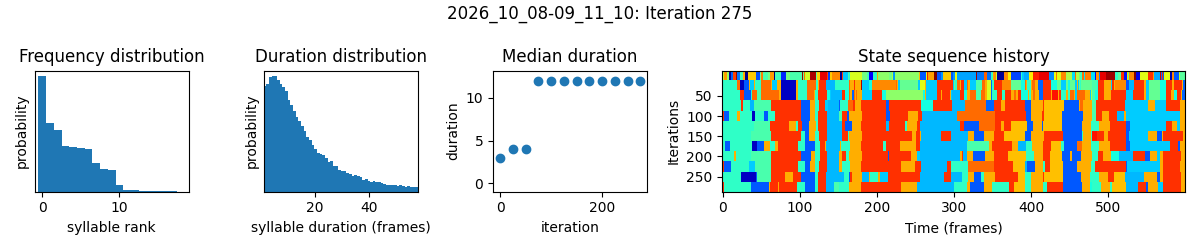

 50%|████████████████▍                | 250/501 [31:22<31:11,  7.46s/it]

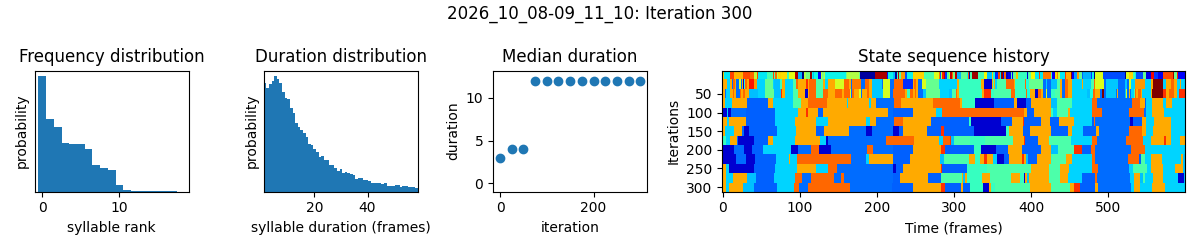

 55%|██████████████████               | 275/501 [34:28<28:02,  7.44s/it]

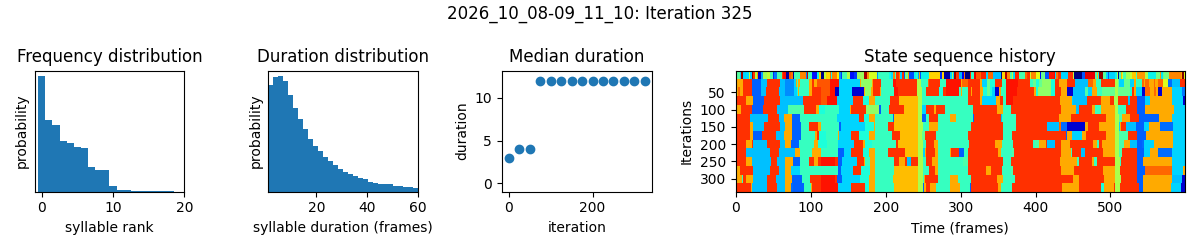

 60%|███████████████████▊             | 300/501 [37:35<24:55,  7.44s/it]

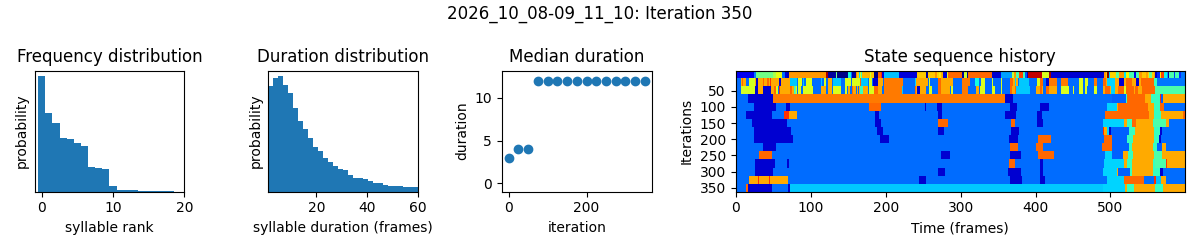

 65%|█████████████████████▍           | 325/501 [40:42<21:50,  7.44s/it]

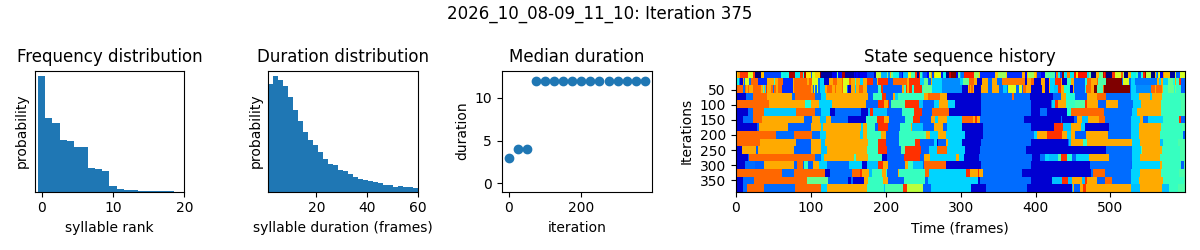

 70%|███████████████████████          | 350/501 [43:48<18:44,  7.45s/it]

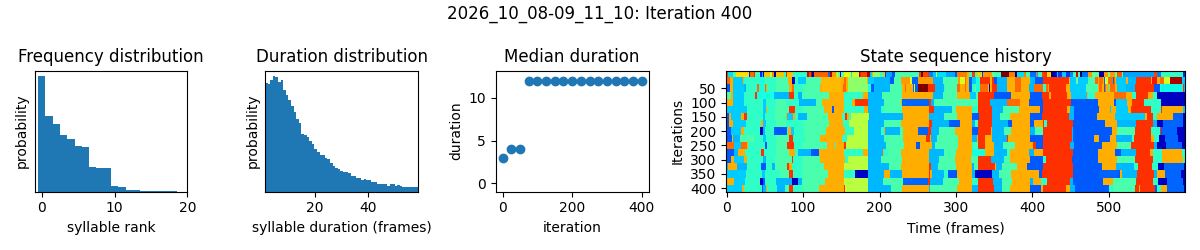

 75%|████████████████████████▋        | 375/501 [46:55<15:39,  7.46s/it]

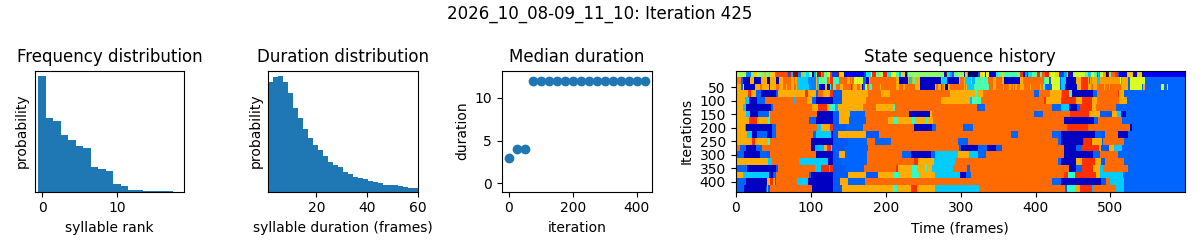

 80%|██████████████████████████▎      | 400/501 [50:01<12:32,  7.45s/it]/usr/local/lib/python3.11/dist-packages/keypoint_moseq/viz.py:582: RuntimeWarning:

More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.



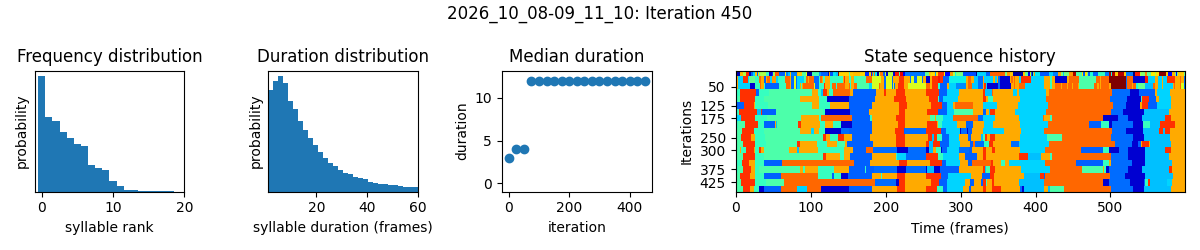

 85%|███████████████████████████▉     | 425/501 [53:08<09:27,  7.46s/it]

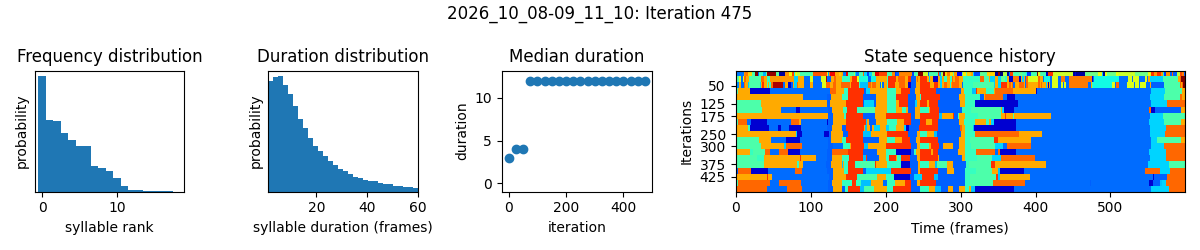

 90%|█████████████████████████████▋   | 450/501 [56:15<06:19,  7.45s/it]

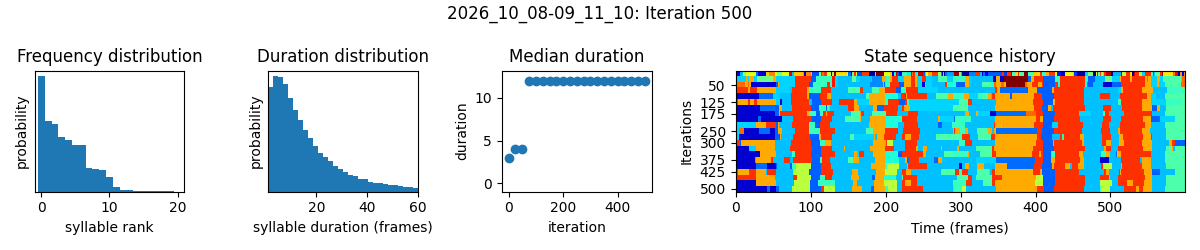

 95%|███████████████████████████████▎ | 475/501 [59:22<03:13,  7.45s/it]

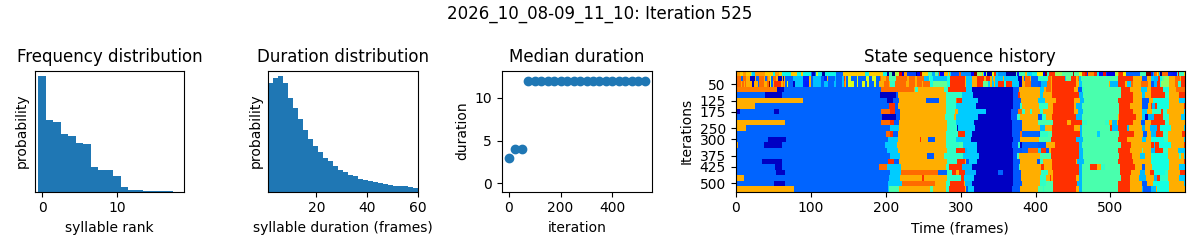

100%|██████████████████████████████▉| 500/501 [1:02:28<00:07,  7.45s/it]

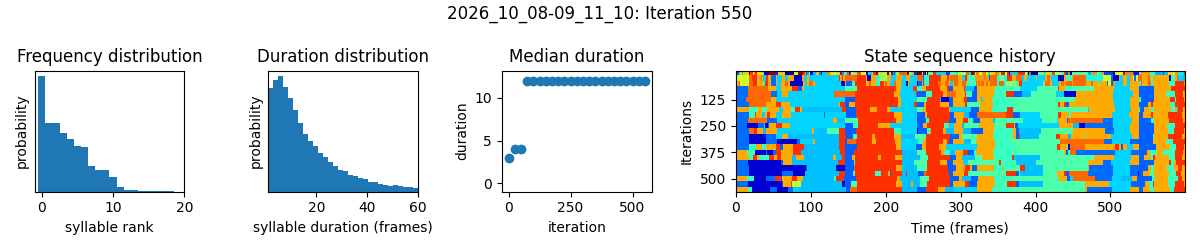

100%|███████████████████████████████| 501/501 [1:02:36<00:00,  7.50s/it]


In [20]:
# load model checkpoint
model, data, metadata, current_iter = kpms.load_checkpoint(
    project_dir, model_name, iteration=num_ar_iters
)

# modify kappa to maintain the desired syllable time-scale
model = kpms.update_hypparams(model, kappa=3e4)

# run fitting for an additional 500 iters
model = kpms.fit_model(
    model,
    data,
    metadata,
    project_dir,
    model_name,
    ar_only=False,
    start_iter=current_iter,
    num_iters=current_iter + 500,
    parallel_message_passing=False,
)[0]

## Sort syllables by frequency

Permute the states and parameters of a saved checkpoint so that syllables are labeled in order of frequency (i.e. so that `0` is the most frequent, `1` is the second most, and so on).

In [ ]:
# modify a saved checkpoint so syllables are ordered by frequency
kpms.reindex_syllables_in_checkpoint(project_dir, model_name);

```{warning}
Reindexing is only applied to the checkpoint file. Therefore, if you perform this step after extracting the modeling results or generating vizualizations, then those steps must be repeated.
```

## Extract model results

Parse the modeling results and save them to `{project_dir}/{model_name}/results.h5`. The results are stored as follows, and can be reloaded at a later time using `kpms.load_results`. Check the docs for an [in-depth explanation of the modeling results](https://keypoint-moseq.readthedocs.io/en/latest/FAQs.html#interpreting-model-outputs).
```
    results.h5
    ├──recording_name1
    │  ├──syllable      # syllable labels (z)
    │  ├──latent_state  # inferred low-dim pose state (x)
    │  ├──centroid      # inferred centroid (v)
    │  └──heading       # inferred heading (h)
    ⋮
```

In [ ]:
# load the most recent model checkpoint
model, data, metadata, current_iter = kpms.load_checkpoint(project_dir, model_name)

# extract results
results = kpms.extract_results(model, metadata, project_dir, model_name)

### [Optional] Save results to csv

After extracting to an h5 file, the results can also be saved as csv files. A separate file will be created for each recording and saved to `{project_dir}/{model_name}/results/`.

In [ ]:
# optionally save results as csv
kpms.save_results_as_csv(results, project_dir, model_name)

## Apply to new data

The code below shows how to apply a trained model to new data. This is useful if you have performed new experiments and would like to maintain an existing set of syllables. The results for the new experiments will be added to the existing `results.h5` file. **This step is optional and can be skipped if you do not have new data to add**.

In [ ]:
# load the most recent model checkpoint and pca object
# model = kpms.load_checkpoint(project_dir, model_name)[0]

# # load new data (e.g. from deeplabcut)
# new_data = 'path/to/new/data/' # can be a file, a directory, or a list of files
# coordinates, confidences, bodyparts = kpms.load_keypoints(new_data, 'deeplabcut')
# coordinates, confidences = kpms.outlier_removal(
#     coordinates,
#     confidences,
#     project_dir,
#     overwrite=False,
#     **config()
# )
# data, metadata = kpms.format_data(coordinates, confidences, **config())

# # apply saved model to new data
# results = kpms.apply_model(model, data, metadata, project_dir, model_name, **config())

# # if applying to data that includes the original training recordings,
# # set overwrite=True to replace the existing results for those recordings
# # results = kpms.apply_model(model, data, metadata, project_dir, model_name, overwrite=True, **config())

# optionally rerun `save_results_as_csv` to export the new results
# kpms.save_results_as_csv(results, project_dir, model_name)

# Visualization

## Trajectory plots
Generate plots showing the median trajectory of poses associated with each given syllable.

In [ ]:
results = kpms.load_results(project_dir, model_name)
kpms.generate_trajectory_plots(coordinates, results, project_dir, model_name, **config())

## Grid movies
Generate video clips showing examples of each syllable.

*Note: the code below will only work with 2D data. For 3D data, see the [FAQ](https://keypoint-moseq.readthedocs.io/en/latest/FAQs.html#making-grid-movies-for-3d-data).*

In [ ]:
kpms.generate_grid_movies(results, project_dir, model_name, coordinates=coordinates, **config());

## Syllable Dendrogram
Plot a dendrogram representing distances between each syllable's median trajectory.

In [ ]:
kpms.plot_similarity_dendrogram(coordinates, results, project_dir, model_name, **config())